<a href="https://colab.research.google.com/github/afdialamsyar/PixelsnPaper/blob/main/electronic_structure_1d_v01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perhitungan Struktur Elektronik pada Sebuah Model Sistem 1d

Pada notebook ini kita akan melakukan perhitungan struktur elektronik sederhana pada model sistem 1d.

Mengapa menggunakan 1d:
- sistem ini kecil sehingga tidak memerlukan resource komputasi yang besar, dapat dijalankan di laptop
- sederhana, dapat diimplementasikan *from scratch*, tanpa menggunakan perangkat lunak khusus

Sistem ini terdiri dari inti atom (bermuatan positif) dan elektron (bermuatan negatif). Inti atom akan dimodelkan sebagai partikel klasik (muatan titik) dan elektron akan dimodelkan secara kuantum (dideskripsikan dengan fungsi gelombang).

Dua kasus interaksi antar elektron:
- diabaikan pada model partikel (elektron) independen dan
- metode Kohn-Sham density functional theory

Interaksi antara inti atom dan elektron dideskripsikan dengan menggunakan potensial *soft-Coulomb*

Interaksi antara elektron-elektron mengunakan potensial *soft-Coulomb*, diaproksimasi dengan fungsional XC khusus untuk jenis potensial ini.

Interaksi antara inti-inti menggunakan potensial Coulomb, inti atom dimodelkan sebagai pertikel titik bermuatan positif.

## Install packages (optional, required in Google Colab)

In [ ]:
using Pkg
Pkg.add("PlotThemes")
Pkg.add("Libxc_jll")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
    Updating `~/.julia/environments/v1.11/Project.toml`
  [ccf2f8ad] + PlotThemes v3.3.0
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
   Installed Libxc_jll ─ v7.0.0+2
    Updating `~/.julia/environments/v1.11/Project.toml`
  [a56a6d9d] + Libxc_jll v7.0.0+2
    Updating `~/.julia/environments/v1.11/Manifest.toml`
  [a56a6d9d] + Libxc_jll v7.0.0+2
Precompiling project...
   1463.3 ms  ✓ Libxc_jll
  1 dependency successfully precompiled in 2 seconds. 468 already precompiled.


## Import beberapa library

In [ ]:
using Printf, LinearAlgebra

In [ ]:
import Plots, PlotThemes
#Plots.theme(:dark) # comment this if not using dark theme

## Fungsi-fungsi untuk finite difference 1d

In [ ]:
function init_FD1d_grid( x_min::Float64, x_max::Float64, N::Int64 )
    L = x_max - x_min
    h = L/(N-1)
    x = zeros(Float64,N)
    for i = 1:N
        x[i] = x_min + (i-1)*h
    end
    return x, h
end
init_FD1d_grid( X, N ) = init_FD1d_grid( X[1], X[2], N )

init_FD1d_grid (generic function with 2 methods)

In [ ]:
Npoints = 50;
xgrid, h = init_FD1d_grid(-5.0, 5.0, Npoints);

In [ ]:
xgrid, h

([-5.0, -4.795918367346939, -4.591836734693878, -4.387755102040816, -4.183673469387755, -3.979591836734694, -3.7755102040816326, -3.571428571428571, -3.36734693877551, -3.163265306122449  …  3.163265306122449, 3.36734693877551, 3.571428571428571, 3.775510204081632, 3.979591836734695, 4.183673469387756, 4.387755102040817, 4.591836734693878, 4.795918367346939, 5.0], 0.20408163265306123)

In [ ]:
function my_gaussian(x, a)
    return exp(-a*x^2)
end

function d2_my_gaussian(x, a)
    return 2*a*(2*a*x^2 - 1)*exp(-a*x^2)
end

d2_my_gaussian (generic function with 1 method)

In [ ]:
f = zeros(Float64, Npoints)
d2f = zeros(Float64, Npoints)
a = 1.1
for i in 1:Npoints
    f[i] = my_gaussian(xgrid[i], a)
    d2f[i] = d2_my_gaussian(xgrid[i], a)
end

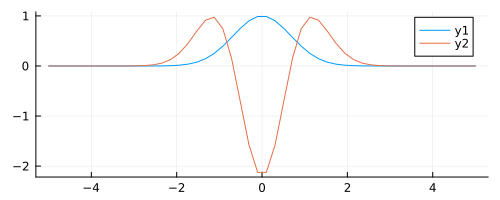

In [ ]:
Plots.plot(xgrid, f, fmt=:svg, size=(500,200))
Plots.plot!(xgrid, d2f)

In [ ]:
"""
Build second derivative matrix using 3-points centered
finite difference approximation.

# Arguments
- `N::Int64`: number of grid points
- `h::Float64`: spacing between grid points
"""
function build_D2_matrix_3pt( N::Int64, h::Float64 )
    mat = zeros(Float64,N,N)
    for i = 1:N-1
        mat[i,i] = -2.0
        mat[i,i+1] = 1.0
        mat[i+1,i] = 1.0
    end
    mat[N,N] = -2.0
    return mat/h^2
end

build_D2_matrix_3pt

In [ ]:
D2 = build_D2_matrix_3pt(Npoints, h);

In [ ]:
d2f_num = D2 * f;

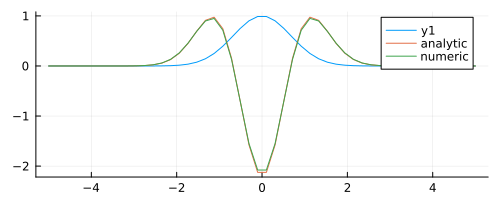

In [ ]:
Plots.plot(xgrid, f, fmt=:svg, size=(500,200))
Plots.plot!(xgrid, d2f, label="analytic")
Plots.plot!(xgrid, d2f_num, label="numeric")

In [ ]:
"""
Build second derivative matrix using 11-points centered
finite difference approximation.

# Arguments
- `N::Int64`: number of grid points
- `h::Float64`: spacing between grid points

f_xx = (8*f[i-5] - 125*f[i-4] + 1000*f[i-3] - 6000*f[i-2] + 42000*f[i-1] - 73766*f[i+0] +
       42000*f[i+1] - 6000*f[i+2] + 1000*f[i+3] - 125*f[i+4] + 8*f[i+5]) / (25200*h**2)
"""
function build_D2_matrix_11pt( N::Int64, h::Float64 )
    mat = zeros(Float64,N,N)
    for i = 1:N-5
        mat[i,i]   = -73766.0
        mat[i,i+1] =  42000.0
        mat[i,i+2] =  -6000.0
        mat[i,i+3] =   1000.0
        mat[i,i+4] =   -125.0
        mat[i,i+5] =      8.0
        mat[i+1,i] =  42000.0
        mat[i+2,i] =  -6000.0
        mat[i+3,i] =   1000.0
        mat[i+4,i] =   -125.0
        mat[i+5,i] =      8.0
    end
    mat[N-4,N-4] = -73766.0
    #
    mat[N-4,N-3] =  42000.0
    mat[N-4,N-2] =  -6000.0
    mat[N-4,N-1] =   1000.0
    mat[N-4,N  ] =   -125.0
    #
    mat[N-3,N-4] = 42000.0
    mat[N-2,N-4] = -6000.0
    mat[N-1,N-4] =  1000.0
    mat[N  ,N-4] =  -125.0
    mat[N-3,N-3] = -73766.0
    #
    mat[N-3,N-2] = 42000.0
    mat[N-3,N-1] = -6000.0
    mat[N-3,N  ] =  1000.0
    #
    mat[N-2,N-3] = 42000.0
    mat[N-1,N-3] = -6000.0
    mat[N  ,N-3] =  1000.0
    mat[N-2,N-2] = -73766.0
    #
    mat[N-2,N-1] =  42000.0
    mat[N-2,N  ] =  -6000.0
    #
    mat[N-1,N-2] =  42000.0
    mat[N  ,N-2] =  -6000.0
    mat[N-1,N-1] = -73766.0
    mat[N-1,N]   = 42000.0
    mat[N,N-1]   = 42000.0
    mat[N,N] = -73766.0
    return mat/(25200*h^2)
end;

In [ ]:
function harm_potential(x)
    return 0.5*x^2
end

harm_potential (generic function with 1 method)

In [ ]:
V = @. harm_potential(xgrid);

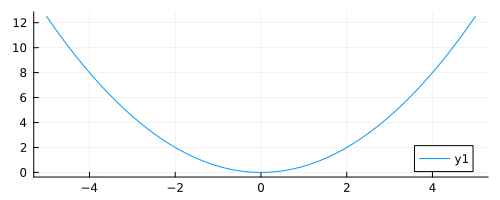

In [ ]:
Plots.plot(xgrid, V, fmt=:svg, size=(500,200))

In [ ]:
Ham = -0.5*D2 + diagm(0=>V);

In [ ]:
energies, wavefuncs = eigen(Ham);

In [ ]:
energies[1:5]

5-element Vector{Float64}:
 0.49869504420754396
 1.4934613991645307
 2.4829591491765157
 3.4671456055636156
 4.445978510842359

In [ ]:
Npoints = 100;
xgrid, h = init_FD1d_grid(-5.0, 5.0, Npoints);
D2 = build_D2_matrix_3pt(Npoints, h);
V = @. harm_potential(xgrid)
Ham = -0.5*D2 + diagm(0=>V);
energies, wavefuncs = eigen(Ham);
println(energies[1:5]')

[0.49968095130194 1.4984039406872967 2.4958479018299897 3.4920107915463063 4.486894261425647]


In [ ]:
Npoints = 100;
xgrid, h = init_FD1d_grid(-5.0, 5.0, Npoints);
D2 = build_D2_matrix_11pt(Npoints, h);
V = @. harm_potential(xgrid)
Ham = -0.5*D2 + diagm(0=>V);
energies, wavefuncs = eigen(Ham);
println(energies[1:5]')

[0.5000000000309601 1.5000000015557229 2.5000000371417803 3.5000005632009747 4.50000608920873]


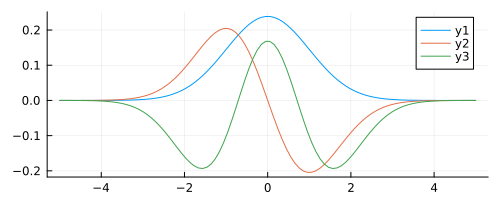

In [ ]:
Plots.plot(xgrid, wavefuncs[:,1], fmt=:svg, size=(500,200))
Plots.plot!(xgrid, wavefuncs[:,2])
Plots.plot!(xgrid, wavefuncs[:,3])

In [ ]:
Focc = [2.0, 1.0]
rho = Focc[1]* (wavefuncs[:,1] .* wavefuncs[:,1]) +
      Focc[2]* (wavefuncs[:,2] .* wavefuncs[:,2]);

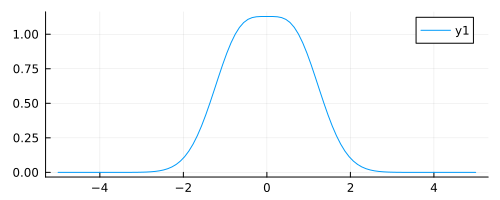

In [ ]:
Plots.plot(xgrid, rho, fmt=:svg, size=(500,200))

In [ ]:
wavefuncs[:,:] = wavefuncs[:,:]/sqrt(h);

In [ ]:
sum(wavefuncs[:,1].^2)*h

1.0000000000000004

In [ ]:
sum(rho)*h

3.000000000000001

## XC stuffs (don't modify this if you don't know what you're doing)

In [ ]:
abstract type AbstractXCCalculator
end

# Use internal XC
struct XCCalculator <: AbstractXCCalculator
end

# Use Libxc
struct LibxcXCCalculator <: AbstractXCCalculator
    Vlapl::Array{Float64,2}
    Vtau::Array{Float64,2}
end

function LibxcXCCalculator( ; is_metagga=false, Npoints=0, Nspin=1 )
    if is_metagga
        @assert Npoints > 0
        Vlapl = zeros(Npoints,Nspin)
        Vtau = zeros(Npoints,Nspin)
        return LibxcXCCalculator(Vlapl, Vtau)
    else
        return LibxcXCCalculator(zeros(1,1),zeros(1,1))
    end
end


using Libxc_jll

# From Libxc.jl v0.1.3
mutable struct XCFuncType
end

const LIBXC5 = Libxc_jll.libxc

function Libxc_xc_func_alloc()
    ccall( (:xc_func_alloc, LIBXC5), Ptr{XCFuncType}, () )
end

function Libxc_xc_func_init( p::Ptr{XCFuncType}, functional::Int, nspin::Int )
    ccall( (:xc_func_init, LIBXC5), Cint, (Ptr{XCFuncType}, Cint, Cint), p, functional, nspin )
end

function Libxc_xc_func_end( p::Ptr{XCFuncType} )
    ccall( (:xc_func_end, LIBXC5), Cvoid, (Ptr{XCFuncType},), p )
end

function Libxc_xc_func_free( p::Ptr{XCFuncType} )
    ccall( (:xc_func_free, LIBXC5), Cvoid, (Ptr{XCFuncType},), p )
end

function Libxc_xc_lda_vxc!(
    p::Ptr{XCFuncType},
    np::Int,
    rho::Array{Float64, 1},
    vrho::Array{Float64, 1}
)
    ccall( (:xc_lda_vxc, LIBXC5), Cvoid,
           (Ptr{XCFuncType}, Cint, Ptr{Float64}, Ptr{Float64}),
           p, np, rho, vrho)

end

function Libxc_xc_lda_exc!(
    p::Ptr{XCFuncType},
    np::Int,
    rho::Array{Float64,1},
    zk::Array{Float64,1}
)
    ccall( (:xc_lda_exc, LIBXC5), Cvoid,
           (Ptr{XCFuncType}, Cint, Ptr{Float64}, Ptr{Float64}),
           p, np, rho, zk
    )
end




function calc_epsxc_1d(
    xc_calc::LibxcXCCalculator,
    Rhoe
)
    Npoints = size(Rhoe,1)
    Nspin = size(Rhoe,2)
    @assert Nspin == 1
    #
    eps_x = zeros(Float64,Npoints)
    eps_c = zeros(Float64,Npoints)
    #
    ptr = Libxc_xc_func_alloc()
    # exchange part
    Libxc_xc_func_init(ptr, 21, Nspin)  # LDA_X_1D_SOFT
    Libxc_xc_lda_exc!(ptr, Npoints, Rhoe[:,1], eps_x)
    Libxc_xc_func_end(ptr)
    #
    # correlation part
    Libxc_xc_func_init(ptr, 18, Nspin) # LDA_C_1D_CSC
    Libxc_xc_lda_exc!(ptr, Npoints, Rhoe[:,1], eps_c)
    Libxc_xc_func_end(ptr)
    #
    Libxc_xc_func_free(ptr)
    return eps_x + eps_c
end

function calc_Vxc_1d(
    xc_calc::LibxcXCCalculator,
    Rhoe
)
    Npoints = size(Rhoe,1)
    Nspin = size(Rhoe,2)
    @assert Nspin == 1
    v_x = zeros(Float64,Npoints)
    v_c = zeros(Float64,Npoints)
    #
    ptr = Libxc_xc_func_alloc()
    # exchange part
    Libxc_xc_func_init(ptr, 21, Nspin)
    Libxc_xc_lda_vxc!(ptr, Npoints, Rhoe[:,1], v_x)
    Libxc_xc_func_end(ptr)
    #
    # correlation part
    Libxc_xc_func_init(ptr, 18, Nspin)
    Libxc_xc_lda_vxc!(ptr, Npoints, Rhoe[:,1], v_c)
    Libxc_xc_func_end(ptr)
    #
    Libxc_xc_func_free(ptr)
    return v_x + v_c
end;

## Beberapa fungsi terkait struktur elektronik

Potensial soft-Coulomb, digunakan untuk memodelkan potensial interaksi antara ion (inti atom) dengan elektron:
$$
V(x) = \sum_{I} -\frac{Z_{I}}{\sqrt{(x - x_I)^2 + a^2}}
$$
dengan $x_0$ adalah posisi atom and $a$ adalah parameter _softening_. Pada studi ini kita akan mengambil nilai $a=1$. Semakin kecil nilai $a$ maka potensial yang dihasilkan akan mendekati potensial Coulomb. $Z$ adalah "nomor atom".

In [ ]:
function pot_soft_coulomb( x; Z=1.0, a=1.0, position=0.0 )
    return -Z/sqrt((x-position)^2 + a^2)
end;

Fungsi untuk menghitung kerapatan elektron:
$$
\rho(r) = \sum_{i} f_{i} | \phi_{i}(r) | ^2
$$

In [ ]:
function calc_rhoe!(Focc, psi, rhoe)
    Npoints = size(psi, 1)
    Nstates = size(psi, 2)
    fill!(rhoe, 0.0)
    for ist in 1:Nstates
        for ip in 1:Npoints
            rhoe[ip] += Focc[ist] * psi[ip,ist] * psi[ip,ist]
        end
    end
    return
end;

Fungsi untuk menghitung potensial Hartree, dengan input kerapatan elektron. Interaksi antar-elektron dimodelkan dengan potensial soft-Coulomb.

In [ ]:
# a is in bohr, softening parameter of soft Coulomb potential
function Poisson_solve_sum!( xgrid, h,
    rho::Vector{Float64}, V::Vector{Float64}; a = 1.0
)
    Npoints = size(rho,1)
    fill!(V, 0.0)
    for ip in 1:Npoints
        xi = xgrid[ip]
        for jp in 1:Npoints
            xj = xgrid[jp]
            dr = sqrt( (xi - xj)^2 + a^2 )
            V[ip] += rho[jp]/dr
        end
        V[ip] = V[ip]*h
    end
    return
end;

In [ ]:
# Fungsi untuk menghitung energi kinetik dari elektron:
function calc_Ekin(D2, Focc, psi, h)
    Ekin = 0.0
    Nstates = size(psi, 2)
    Kpsi = -0.5*D2*psi
    for ist in 1:Nstates
        Ekin += Focc[ist]*dot(psi[:,ist], Kpsi[:,ist])*h
    end
    return Ekin
end;

## Energi total dengan Independent particle approximation

Fungsi untuk menghitung energi total dari sistem dengan menggunakan model atau aproksimasi partikel independen (independent particle model).
Silakan modifikasi sistem ini menurut kebutuhan.

In [ ]:
function calc_indep_particles_energy(
    xmin, xmax, Npoints,
    Natoms, Zatoms, Xatoms, Nstates, Focc;
    verbose=false
)

    Nelectrons = sum(Zatoms)

    # Some checks
    @assert length(Xatoms) == Natoms
    @assert length(Focc) == Nstates
    @assert sum(Focc) ≈ Nelectrons

    # Initialize the grid points
    xgrid, h = init_FD1d_grid(xmin, xmax, Npoints)

    # Build 2nd derivative matrix
    D2 = build_D2_matrix_11pt(Npoints, h)

    # Potential
    Vion = zeros(Float64, Npoints)
    for ia in 1:Natoms
        Vion[:] .+= pot_soft_coulomb.(xgrid, Z=Zatoms[ia], position=Xatoms[ia])
    end

    Enn = 0.0
    for ia in 1:Natoms, j in (ia+1):Natoms
        Enn += Zatoms[ia]*Zatoms[ia+1]/abs(Xatoms[ia] - Xatoms[ia+1])
    end

    # Hamiltonian
    Ham = -0.5*D2 + diagm( 0 => Vion )

    evals_all, evecs_all = eigen(Ham)

    Ebands = sum(Focc .* evals_all[1:Nstates])
    Etotal = Ebands + Enn
    return (;
        Etotal=Etotal, Vion=Vion, eorbs=evals_all[1:Nstates], psi=evecs_all[:,1:Nstates], xgrid=xgrid, h=h
    )
end;

## Energi total dengan Kohn-Sham DFT

Fungsi untuk menghitung energi total sistem dengan menggunakan Kohn-Sham _density functional theory_. Silakan modifikasi sesuai kebutuhan.

In [ ]:
function calc_dft_energy(
    xmin, xmax, Npoints,
    Natoms, Zatoms, Xatoms, Nstates, Focc;
    verbose = true, β_mix = 0.2, NmaxIterSCF = 100
)

    Nelectrons = sum(Zatoms)

    # Some checks
    @assert length(Xatoms) == Natoms
    @assert length(Focc) == Nstates
    @assert sum(Focc) ≈ Nelectrons


    # Initialize the grid points
    xgrid, h = init_FD1d_grid(xmin, xmax, Npoints)

    # Build 2nd derivative matrix
    D2 = build_D2_matrix_11pt(Npoints, h)

    # Potential
    Vion = zeros(Float64, Npoints)
    for ia in 1:Natoms
        Vion[:] .+= pot_soft_coulomb.(xgrid, Z=Zatoms[ia], position=Xatoms[ia])
    end

    Vtot = zeros(Float64, Npoints)
    Vhartree = zeros(Float64, Npoints)
    rhoe = zeros(Float64, Npoints)
    rhoe_new = zeros(Float64, Npoints)

    xc_calc = LibxcXCCalculator()
    Vxc = zeros(Float64, Npoints)
    epsxc = zeros(Float64, Npoints)

    Ham = zeros(Float64, Npoints, Npoints)
    evals_all = zeros(Float64, Npoints)
    evecs_all = zeros(Float64, Npoints, Npoints)
    psi = zeros(Float64, Npoints, Nstates)
    eorbs = zeros(Float64, Nstates)

    Ekin = Inf
    Ehartree = Inf
    Eion = Inf # interaction of electrons-ions
    Exc  = Inf
    Etotal = Inf
    #
    Etotal_old = Etotal
    Enn = 0.0
    for ia in 1:Natoms, j in (ia+1):Natoms
        Enn += Zatoms[ia]*Zatoms[ia+1]/abs(Xatoms[ia] - Xatoms[ia+1])
    end

    is_converged = false
    #
    # SCF iterations
    #
    # Initial rhoe (random)
    rhoe = rand(Float64, Npoints)
    integRhoe = sum(rhoe)*h
    rhoe[:] *= Nelectrons/integRhoe
    verbose && println("integ initial rhoe = ", sum(rhoe)*h)

    for iter_scf in 1:NmaxIterSCF

        # Update the potentials
        Poisson_solve_sum!(xgrid, h, rhoe, Vhartree)
        Vxc[:] = calc_Vxc_1d(xc_calc, rhoe)

        # Hamiltonian
        Vtot[:] = Vion[:] + Vhartree[:] + Vxc[:]
        Ham[:,:] = -0.5*D2 + diagm( 0 => Vtot )

        # Solve the eigenproblem
        evals_all[:], evecs_all[:,:] = eigen( Ham )
        psi[:,:] = evecs_all[:,1:Nstates]
        eorbs[:] = evals_all[1:Nstates]
        # Renormalize
        psi[:,:] = psi[:,:]/sqrt(h)

        calc_rhoe!(Focc, psi, rhoe_new)
        verbose && println("integ rhoe_new = ", sum(rhoe_new)*h)

        epsxc[:] = calc_epsxc_1d(xc_calc, rhoe_new)
        Ekin = calc_Ekin(D2, Focc, psi, h)
        Ehartree = 0.5*dot(rhoe_new, Vhartree)*h
        Eion = dot(rhoe_new, Vion)*h
        Exc = dot(rhoe_new, epsxc)*h
        Etotal = Ekin + Ehartree + Eion + Exc + Enn

        ΔE = abs(Etotal - Etotal_old)
        mae_rhoe = sum(abs.(rhoe - rhoe_new))/Npoints
        verbose && @printf("%3d %18.10f %10.5e %10.5e\n", iter_scf, Etotal, ΔE, mae_rhoe)

        if mae_rhoe < 1e-7 || ΔE < 1e-7
            verbose && println("Converged")
            is_converged = true
            break
        end

        # Simple density mix
        if iter_scf >= 2
            rhoe[:] = β_mix*rhoe_new[:] + (1 - β_mix)*rhoe[:]
        else
            rhoe[:] = rhoe_new[:]
        end
        Etotal_old = Etotal

    end

    if verbose
        @printf("Orbital energies\n")
        for ist in 1:Nstates
            @printf("%5d %18.10f\n", ist, eorbs[ist])
        end
        #
        @printf("Total energy components:\n")
        @printf("Ekin     = %18.10f\n", Ekin)
        @printf("Eion     = %18.10f\n", Eion)
        @printf("Ehartree = %18.10f\n", Ehartree)
        @printf("Exc      = %18.10f\n", Exc)
        @printf("Enn      = %18.10f\n", Enn)
        @printf("----------------------\n")
        @printf("Etotal   = %18.10f\n", Etotal)
    end

    if !is_converged
        @warn "SCF is not converged"
    end

    # Return NamedTuple for simplicity
    return (; Etotal=Etotal, Vion=Vion, eorbs=eorbs, psi=psi, xgrid=xgrid, h=h )
end;

## Beberapa hal yang perlu didiskusikan

- Konvergensi energi total terhadap `Npoints`
- Perbandingan antara potensial soft-Coulomb dan Coulomb
- Visualisasi orbital keadaan terikat dan tak-terikat (bound states vs unbound states)
- Visualisasi orbital ikatan dan non-ikatan
- Perbandingan dengan metode Hartree (mirip dengan Kohn-Sham DFT, namun tanpa suku *exchange-correlation*
- Perbandingan dengan metode Hartree-Fock?
- ...



## Pengembangan lanjut

- Sistem periodik, struktur pita (band structure)
- Spin-polarized
- Smearing (fractional occupations), metallic system
- Gaya pada atom, optimisasi geometri, gaya pada atom
- Metode alternatif untuk menyelesaikan persamaan Kohn-Sham

## Contoh inisialisasi grid

In [ ]:
Npoints = 50
xgrid, h = init_FD1d_grid(-5.0, 5.0, Npoints);

In [ ]:
Vion = zeros(Float64, Npoints)
Vion_coulomb = zeros(Float64, Npoints)
for i in 1:Npoints
    Vion[i] = pot_soft_coulomb( xgrid[i]; Z=1.0, a=1.0, position=0.0 )
    Vion_coulomb[i] = -1.0/abs(xgrid[i])
end;

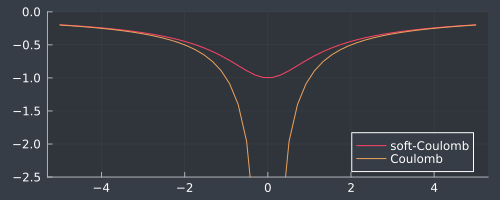

In [ ]:
Plots.plot(xgrid, Vion, fmt=:svg, size=(500,200), label="soft-Coulomb")
Plots.plot!(xgrid, Vion_coulomb, label="Coulomb")
Plots.ylims!(-2.5, 0)

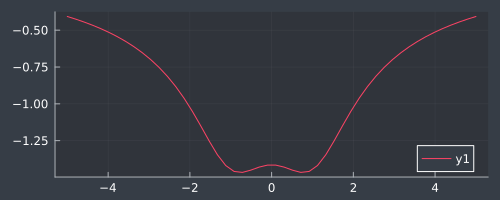

In [ ]:
Vion = zeros(Float64, Npoints)
for i in 1:Npoints
    Vion[i] = pot_soft_coulomb( xgrid[i], position=-1.0 ) + pot_soft_coulomb( xgrid[i], position=1.0 )
end;
Plots.plot(xgrid, Vion, fmt=:svg, size=(500,200))

## Contoh penggunaan`calc_indep_particles_energy`

In [ ]:
xmin = -5.0
xmax =  5.0
Npoints = 51

Natoms = 2
Zatoms = [1, 1] # each atoms contains 1 electrons
Xatoms = [-1.0, 1.0]

Nstates = 2
Focc = [2.0, 0.0] # manually

result = calc_indep_particles_energy(
    xmin, xmax, Npoints,
    Natoms, Zatoms, Xatoms, Nstates, Focc, verbose=false
);

In [ ]:
xgrid = result.xgrid;
psi = result.psi;
Vion = result.Vion;

In [ ]:
result.eorbs

2-element Vector{Float64}:
 -1.2578549081516555
 -0.8297856623596456

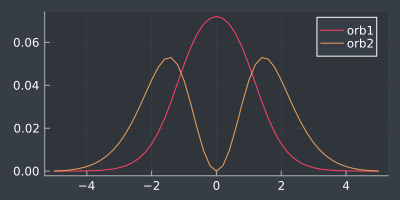

In [ ]:
Plots.plot(xgrid, psi[:,1].^2, size=(400,200), fmt=:svg, label="orb1")
Plots.plot!(xgrid, psi[:,2].^2, label="orb2")

In [ ]:
result.Etotal

-2.015709816303311

In [ ]:
result.eorbs .* Focc

2-element Vector{Float64}:
 -2.515709816303311
 -0.0

## Contoh penggunaan `calc_dft_energy`

In [ ]:
xmin = -5.0
xmax =  5.0
Npoints = 51

Natoms = 2
Zatoms = [1, 1] # each atoms contains 2 electrons
Xatoms = [-1.5, 1.5]

Nstates = 2
Focc = [2.0, 0.0] # manually

result = calc_dft_energy(
    xmin, xmax, Npoints,
    Natoms, Zatoms, Xatoms, Nstates, Focc, verbose=false
);

In [ ]:
xgrid = result.xgrid;
psi = result.psi;
Vion = result.Vion;

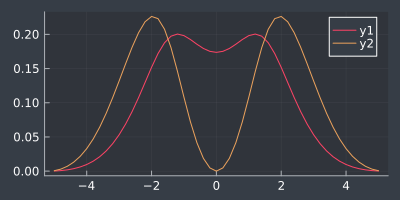

In [ ]:
Plots.plot(xgrid, psi.^2, size=(400,200), fmt=:svg)

In [ ]:
result.Etotal

-1.325727770567217

## Eksplorasi test dimer

In [ ]:
xmin = -15.0
xmax =  15.0
Npoints = 201

Natoms = 2
Zatoms = [1, 1]
Xatoms = zeros(Float64, Natoms) # will be set later

Nstates = 1
Focc = [2.0] # manually

distances = collect(0.6:0.2:5.0)
energies_dft = zeros(Float64, length(distances))
energies_ip = zeros(Float64, length(distances))
for i in 1:length(distances)
    # Set Xatoms
    Xatoms[1] = -distances[i]/2
    Xatoms[2] =  distances[i]/2
    #
    result_dft = calc_dft_energy(
        xmin, xmax, Npoints,
        Natoms, Zatoms, Xatoms, Nstates, Focc, verbose=false
    )
    energies_dft[i] = result_dft.Etotal
    #
    result_ip = calc_indep_particles_energy(
        xmin, xmax, Npoints,
        Natoms, Zatoms, Xatoms, Nstates, Focc;
    )
    energies_ip[i] = result_ip.Etotal
end

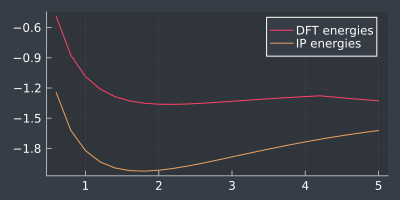

In [ ]:
Plots.plot(distances, energies_dft, label="DFT energies", fmt=:svg, size=(400,200))
Plots.plot!(distances, energies_ip, label="IP energies")

In [ ]:
minimum(energies_dft), argmin(energies_dft)

(-1.3621522537282031, 9)

In [ ]:
distances[9]

2.2

In [ ]:
minimum(energies_ip), argmin(energies_ip)

(-2.0246761780172804, 7)

In [ ]:
distances[7]

1.8